In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [3]:
df = pd.read_csv(r"D:\DEPI R4 ML\Data Sets\diabetes.csv") 
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [11]:

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(8, activation='relu'),                         
    Dense(1, activation='sigmoid')                          
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, 
                    epochs=10, 
                    batch_size=10, 
                    validation_split=0.1, 
                    verbose=1)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6594 - loss: 0.6967 - val_accuracy: 0.5806 - val_loss: 0.6978
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6612 - loss: 0.6097 - val_accuracy: 0.5645 - val_loss: 0.6389
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6649 - loss: 0.5619 - val_accuracy: 0.6129 - val_loss: 0.6046
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6866 - loss: 0.5337 - val_accuracy: 0.6129 - val_loss: 0.5820
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7029 - loss: 0.5151 - val_accuracy: 0.5968 - val_loss: 0.5640
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7283 - loss: 0.5021 - val_accuracy: 0.6290 - val_loss: 0.5527
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7446 - loss: 0.4916 - val_accuracy: 0.6613 - val_loss: 0.5424
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7609 - loss: 0.4814 - val_accuracy: 0.6774 - val_loss

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7597 - loss: 0.5333

Model Accuracy: 75.97%


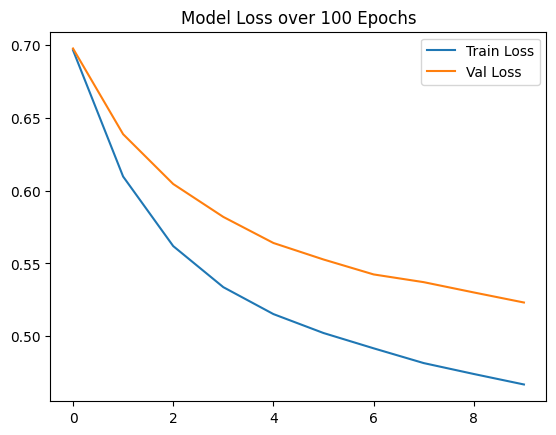

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss over 100 Epochs')
plt.legend()
plt.show()